In [1]:
#importing Libraries
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import ipywidgets as widgets
from IPython.display import display
import joblib
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()


Saving data_private_forModel.xlsx to data_private_forModel.xlsx


In [3]:
# Sau khi tải lên, bạn có thể đọc file Excel như sau:
import pandas as pd
df = pd.read_excel('data_private_forModel.xlsx')
df.head()

,ChamNoi,CungNhac,CoLap,HanhViLapLai,KyNangGiaoTiepSom,ChoiLuanPhien,PhanUngTenGoi,DiNhonChan,ChiTro,TiepXucMat,TargetBinary
0,0,0,0,0,0.0,0.0,0.0,0,0.5,0.0,1
1,0,0,0,0,0.0,0.0,0.0,0,0.0,0.0,1
2,0,0,0,1,0.5,0.0,0.0,0,1.0,0.5,1
3,1,0,0,0,0.5,0.0,0.0,0,1.0,0.0,1
4,0,0,0,0,0.0,0.0,0.0,0,0.0,0.5,1


In [4]:
for i, col in enumerate(df.columns):
    print(f"Vị trí {i}: {col}")

Vị trí 0: ChamNoi
Vị trí 1: CungNhac
Vị trí 2: CoLap
Vị trí 3: HanhViLapLai
Vị trí 4: KyNangGiaoTiepSom
Vị trí 5: ChoiLuanPhien
Vị trí 6: PhanUngTenGoi
Vị trí 7: DiNhonChan
Vị trí 8: ChiTro
Vị trí 9: TiepXucMat
Vị trí 10: TargetBinary


In [5]:
# Liệt kê tên các cột
print(df.columns.tolist())
rows, cols = df.shape
print(f"Số hàng: {rows}, Số cột: {cols}")

['ChamNoi', 'CungNhac', 'CoLap', 'HanhViLapLai', 'KyNangGiaoTiepSom', 'ChoiLuanPhien', 'PhanUngTenGoi', 'DiNhonChan', 'ChiTro', 'TiepXucMat', 'TargetBinary']
Số hàng: 864, Số cột: 11


In [6]:
X = df.iloc[:, 0:10]      # lấy từ cột 0 đến 13 (14 đặc trưng)
y = df.iloc[:, 10]        # lấy cột TargetBinary (vị trí 14)

# TRAINING VÀ ĐÁNH GIÁ MODEL

==== Đánh giá mô hình Decision Tree (chạy đơn) ====
Accuracy:     0.965
Recall:       0.949
Specificity:  0.987
Precision:    0.989
F1-score:     0.969
ROC AUC:      0.986
G-Mean:       0.968

=== Độ quan trọng của các đặc trưng (giảm dần) ===
Feature: TiepXucMat, Score: 0.86966
Feature: ChamNoi, Score: 0.08989
Feature: HanhViLapLai, Score: 0.02754
Feature: CungNhac, Score: 0.00859
Feature: KyNangGiaoTiepSom, Score: 0.00298
Feature: PhanUngTenGoi, Score: 0.00067
Feature: ChiTro, Score: 0.00067
Feature: CoLap, Score: 0.00000
Feature: ChoiLuanPhien, Score: 0.00000
Feature: DiNhonChan, Score: 0.00000


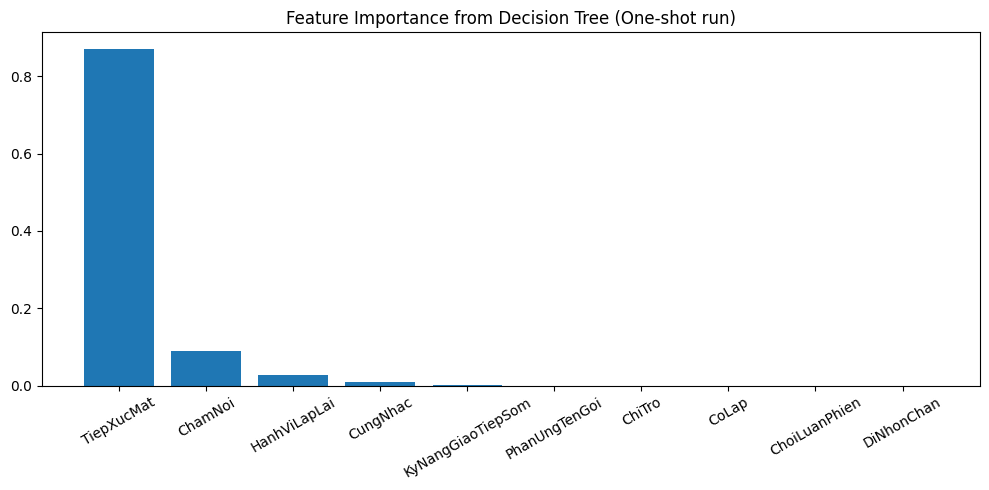

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
)
from imblearn.metrics import geometric_mean_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Tách tập huấn luyện và kiểm tra
X = df.drop(columns='TargetBinary')
y = df['TargetBinary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Tạo pipeline
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=7,
    max_leaf_nodes=10,
    min_samples_leaf=4,
    min_samples_split=2,
    random_state=42
)
pipeline = Pipeline(steps=[('imputer', SimpleImputer()), ('model', model)])

# 3. Huấn luyện mô hình
pipeline.fit(X_train, y_train)

# 4. Dự đoán và đánh giá
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Confusion matrix và các độ đo mở rộng
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
gmean = np.sqrt(recall * specificity)

# 5. In kết quả
print("==== Đánh giá mô hình Decision Tree (chạy đơn) ====")
print(f"Accuracy:     {accuracy:.3f}")
print(f"Recall:       {recall:.3f}")
print(f"Specificity:  {specificity:.3f}")
print(f"Precision:    {precision:.3f}")
print(f"F1-score:     {f1:.3f}")
print(f"ROC AUC:      {roc_auc:.3f}")
print(f"G-Mean:       {gmean:.3f}")

# 6. Tầm quan trọng của đặc trưng
importances = pipeline.named_steps['model'].feature_importances_
feature_names = X.columns
feature_importance = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

print("\n=== Độ quan trọng của các đặc trưng (giảm dần) ===")
for name, score in feature_importance:
    print(f'Feature: {name}, Score: {score:.5f}')

# 7. Biểu đồ độ quan trọng
sorted_names, sorted_scores = zip(*feature_importance)
plt.figure(figsize=(10, 5))
plt.bar(sorted_names, sorted_scores)
plt.xticks(rotation=30)
plt.title('Feature Importance from Decision Tree (One-shot run)')
plt.tight_layout()
plt.show()


# Cross-Validation

In [10]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix
)
import numpy as np
import pandas as pd

# 2. Thiết lập Stratified K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Danh sách lưu độ đo cho từng Fold
results = []

# 4. Lặp qua từng fold
fold = 1
for train_index, test_index in kf.split(X, y):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train_fold, y_train_fold)
    y_pred = model.predict(X_test_fold)
    y_proba = model.predict_proba(X_test_fold)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test_fold, y_pred).ravel()

    accuracy = accuracy_score(y_test_fold, y_pred)
    recall = recall_score(y_test_fold, y_pred)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = precision_score(y_test_fold, y_pred)
    f1 = f1_score(y_test_fold, y_pred)
    roc_auc = roc_auc_score(y_test_fold, y_proba)
    gmean = np.sqrt(recall * specificity)

    results.append({
        "Fold": fold,
        "Accuracy": accuracy,
        "Recall": recall,
        "Specificity": specificity,
        "Precision": precision,
        "F1-score": f1,
        "ROC AUC": roc_auc,
        "G-Mean": gmean
    })
    fold += 1

# 5. Tạo DataFrame kết quả
results_df = pd.DataFrame(results)

# 6. Thêm dòng Trung bình
mean_row = {
    "Fold": "Trung bình",
    "Accuracy": results_df["Accuracy"].mean(),
    "Recall": results_df["Recall"].mean(),
    "Specificity": results_df["Specificity"].mean(),
    "Precision": results_df["Precision"].mean(),
    "F1-score": results_df["F1-score"].mean(),
    "ROC AUC": results_df["ROC AUC"].mean(),
    "G-Mean": results_df["G-Mean"].mean()
}
results_df = pd.concat([results_df, pd.DataFrame([mean_row])], ignore_index=True)

# Làm tròn
results_df.iloc[:, 1:] = results_df.iloc[:, 1:].round(3)

# 7. In kết quả
print("==== Kết quả Cross-Validation cho Decision Tree ====")
print(results_df.to_string(index=False))


==== Kết quả Cross-Validation cho Decision Tree ====
      Fold  Accuracy  Recall  Specificity  Precision  F1-score  ROC AUC  G-Mean
         1     0.977   0.969        0.987      0.990     0.979    0.993   0.978
         2     0.965   0.959        0.973      0.979     0.969    0.994   0.966
         3     0.977   0.969        0.987      0.990     0.979    0.983   0.978
         4     0.983   1.000        0.960      0.970     0.985    1.000   0.980
         5     0.959   0.928        1.000      1.000     0.963    0.978   0.963
Trung bình     0.972   0.965        0.981      0.986     0.975    0.990   0.973
